In [10]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
%run '/content/drive/MyDrive/Repos/MachineLearning-ML001/helper/helper.ipynb'

# Supervised Data Compression via Linear Discriminant Analysis (LDA)

## 1. Introduction to LDA

Linear Discriminant Analysis (LDA) is a feature extraction technique used to increase computational efficiency and reduce the degree of overfitting caused by the curse of dimensionality in non-regularized models.

### PCA vs. LDA

Both PCA and LDA are linear transformation techniques used for dimensionality reduction.

* **PCA (Principal Component Analysis):** An *unsupervised* algorithm that attempts to find orthogonal component axes of maximum variance.
* **LDA:** A *supervised* algorithm that aims to find the feature subspace that optimizes class separability.

### Assumptions of LDA

LDA assumes that the data is normally distributed, classes have identical covariance matrices, and training examples are statistically independent. However, LDA can still work reasonably well even if these assumptions are slightly violated.

### The 7 Main Steps of LDA

1. Standardize the $d$-dimensional dataset ($d$ is the number of features).
2. For each class, compute the $d$-dimensional mean vector.
3. Construct the between-class scatter matrix, $S_B$, and the within-class scatter matrix, $S_W$.
4. Compute the eigenvectors and corresponding eigenvalues of the matrix $S_W^{-1}S_B$.
5. Sort the eigenvalues by decreasing order to rank the corresponding eigenvectors.
6. Choose the $k$ eigenvectors that correspond to the $k$ largest eigenvalues to construct a $d \times k$-dimensional transformation matrix, $W$.
7. Project the examples onto the new feature subspace using the transformation matrix, $W$.

---

## 2. Step-by-Step Manual Implementation

### Step 1: Standardization

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the Wine dataset
df_wine = pd.read_csv(
    'https://archive.ics.uci.edu/ml/machine-learning-databases/wine/wine.data',
    header=None
)

# Split into features (X) and target labels (y)
X, y = df_wine.iloc[:, 1:].values, df_wine.iloc[:, 0].values

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=0
)

# Standardize the features
sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
X_test_std = sc.transform(X_test)

### Step 2: Computing Mean Vectors

Each mean vector, $\mathbf{m}_i$, stores the mean feature value with respect to the examples of class $i$:


$$ \mathbf{m}_i = \frac{1}{n_i} \sum_{\mathbf{x} \in D_i} \mathbf{x} $$

In [13]:
import numpy as np

np.set_printoptions(precision=4)
mean_vecs = []

# Calculate mean vectors for each of the 3 classes
for label in range(1, 4):
    mean_vecs.append(np.mean(X_train_std[y_train == label], axis=0))
    print(f'MV {label}: {mean_vecs[label - 1]}\n')

MV 1: [ 0.9066 -0.3497  0.3201 -0.7189  0.5056  0.8807  0.9589 -0.5516  0.5416
  0.2338  0.5897  0.6563  1.2075]

MV 2: [-0.8749 -0.2848 -0.3735  0.3157 -0.3848 -0.0433  0.0635 -0.0946  0.0703
 -0.8286  0.3144  0.3608 -0.7253]

MV 3: [ 0.1992  0.866   0.1682  0.4148 -0.0451 -1.0286 -1.2876  0.8287 -0.7795
  0.9649 -1.209  -1.3622 -0.4013]



### Step 3: Constructing Scatter Matrices

**Within-class scatter matrix ($S_W$):**


$$ S_W = \sum_{i=1}^{c} S_i $$


Where individual scatter matrices are:


$$ S_i = \sum_{\mathbf{x} \in D_i} (\mathbf{x} - \mathbf{m}_i)(\mathbf{x} - \mathbf{m}_i)^T $$

Because class labels are rarely uniformly distributed, it is better to compute the *scaled* within-class scatter matrix, which is mathematically the same as computing the covariance matrix $\Sigma_i$:


$$ \Sigma_i = \frac{1}{n_i} S_i = \frac{1}{n_i} \sum_{\mathbf{x} \in D_i} (\mathbf{x} - \mathbf{m}_i)(\mathbf{x} - \mathbf{m}_i)^T $$

In [14]:
d = 13 # number of features
S_W = np.zeros((d, d))

# Compute scaled within-class scatter matrix (covariance matrix)
for label, mv in zip(range(1, 4), mean_vecs):
    class_scatter = np.cov(X_train_std[y_train == label].T)
    S_W += class_scatter

print('Scaled within-class scatter matrix: '
      f'{S_W.shape[0]}x{S_W.shape[1]}')

Scaled within-class scatter matrix: 13x13


**Between-class scatter matrix ($S_B$):**


$$ S_B = \sum_{i=1}^{c} n_i (\mathbf{m}_i - \mathbf{m})(\mathbf{m}_i - \mathbf{m})^T $$


Here, $\mathbf{m}$ is the overall mean computed including examples from all classes.

In [15]:
mean_overall = np.mean(X_train_std, axis=0)
mean_overall = mean_overall.reshape(d, 1) # make column vector
S_B = np.zeros((d, d))

for i, mean_vec in enumerate(mean_vecs):
    n = X_train_std[y_train == i + 1, :].shape[0]
    mean_vec = mean_vec.reshape(d, 1) # make column vector
    S_B += n * (mean_vec - mean_overall).dot((mean_vec - mean_overall).T)

print('Between-class scatter matrix: '
      f'{S_B.shape[0]}x{S_B.shape[1]}')

Between-class scatter matrix: 13x13


### Steps 4 & 5: Selecting Linear Discriminants

Solve the generalized eigenvalue problem for the matrix $S_W^{-1}S_B$ and sort the eigenvalues in descending order.

In [16]:
# Compute eigenvectors and eigenvalues
eigen_vals, eigen_vecs = np.linalg.eig(np.linalg.inv(S_W).dot(S_B))

# Sort eigenvalues in descending order
eigen_pairs = [(np.abs(eigen_vals[i]), eigen_vecs[:, i])
               for i in range(len(eigen_vals))]
eigen_pairs = sorted(eigen_pairs, key=lambda k: k[0], reverse=True)

print('Eigenvalues in descending order:\n')
for eigen_val in eigen_pairs:
    print(eigen_val[0])

Eigenvalues in descending order:

349.61780890599397
172.7615221897938
3.277875948160424e-14
2.842170943040401e-14
2.6347620763320822e-14
2.6347620763320822e-14
1.7169492680170306e-14
1.7169492680170306e-14
1.674335053365992e-14
1.2740060380615543e-14
7.458378098449665e-15
4.737048557054326e-15
3.688843187314971e-15


**Plot discriminability**

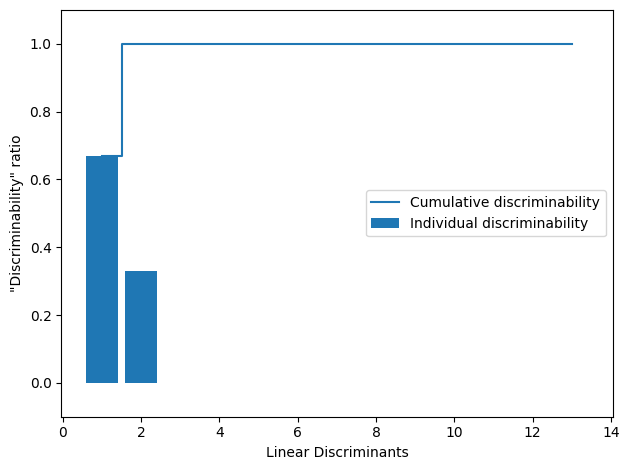

In [17]:
import matplotlib.pyplot as plt

tot = sum(eigen_vals.real)
discr = [(i / tot) for i in sorted(eigen_vals.real, reverse=True)]
cum_discr = np.cumsum(discr)

plt.bar(range(1, 14), discr, align='center', label='Individual discriminability')
plt.step(range(1, 14), cum_discr, where='mid', label='Cumulative discriminability')
plt.ylabel('"Discriminability" ratio')
plt.xlabel('Linear Discriminants')
plt.ylim([-0.1, 1.1])
plt.legend(loc='best')
plt.tight_layout()
plt.show()

### Steps 6 & 7: Projecting Examples onto New Feature Space

Create the transformation matrix $W$ from the top 2 discriminants and transform the dataset $\mathbf{X}' = \mathbf{X}W$.

Matrix W:
 [[-0.1481 -0.4092]
 [ 0.0908 -0.1577]
 [-0.0168 -0.3537]
 [ 0.1484  0.3223]
 [-0.0163 -0.0817]
 [ 0.1913  0.0842]
 [-0.7338  0.2823]
 [-0.075  -0.0102]
 [ 0.0018  0.0907]
 [ 0.294  -0.2152]
 [-0.0328  0.2747]
 [-0.3547 -0.0124]
 [-0.3915 -0.5958]]


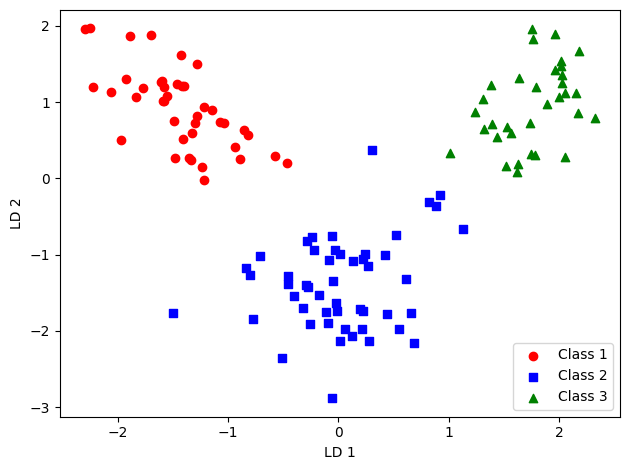

In [18]:
# Stack the two most discriminative eigenvector columns
w = np.hstack((eigen_pairs[0][1][:, np.newaxis].real,
               eigen_pairs[1][1][:, np.newaxis].real))
print('Matrix W:\n', w)

# Transform the training dataset
X_train_lda = X_train_std.dot(w)

# Plot the projected examples
colors = ['r', 'b', 'g']
markers = ['o', 's', '^']

for l, c, m in zip(np.unique(y_train), colors, markers):
    plt.scatter(X_train_lda[y_train == l, 0],
                X_train_lda[y_train == l, 1] * (-1),
                c=c, label=f'Class {l}', marker=m)

plt.xlabel('LD 1')
plt.ylabel('LD 2')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

---

## 3. LDA via scikit-learn

The step-by-step process can be performed conveniently using the `LinearDiscriminantAnalysis` class in scikit-learn.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


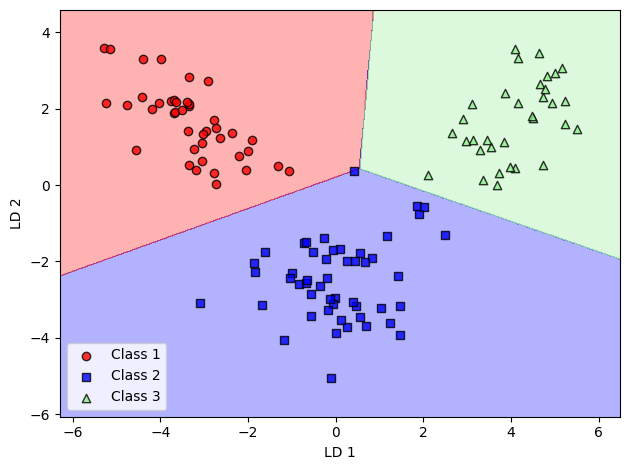

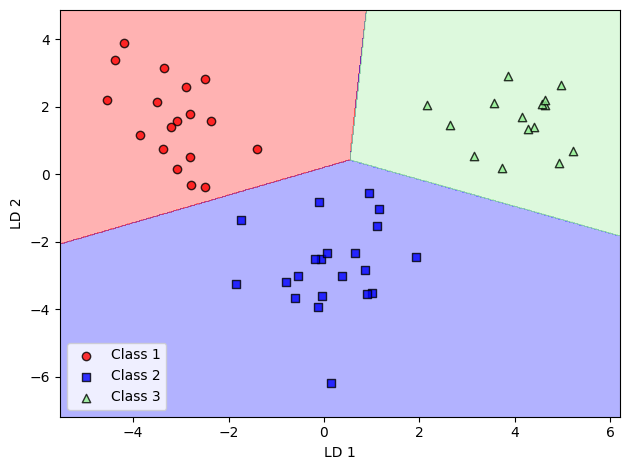

In [19]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.linear_model import LogisticRegression

# Initialize and transform the data using LDA
lda = LDA(n_components=2)
X_train_lda = lda.fit_transform(X_train_std, y_train)
X_test_lda = lda.transform(X_test_std)

# Train a logistic regression model on the reduced dataset
lr = LogisticRegression(multi_class='ovr', random_state=1, solver='lbfgs')
lr.fit(X_train_lda, y_train)

# Plot decision regions for the training dataset (assuming plot_decision_regions function is defined)
plot_decision_regions(X_train_lda, y_train, classifier=lr)
plt.xlabel('LD 1')
plt.ylabel('LD 2')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

# Plot decision regions for the test dataset
plot_decision_regions(X_test_lda, y_test, classifier=lr)
plt.xlabel('LD 1')
plt.ylabel('LD 2')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()